### 01) Notebook 03 — Mini-Grid Dispatch

This notebook simulates rule-based battery dispatch for two scenarios:

- Scenario A: PV generated from actual irradiance
- Scenario B: PV generated from forecast irradiance

The battery dispatch is intentionally simple:

- if PV exceeds load, charge the battery until the power or energy limit is reached
- if load exceeds PV, discharge the battery until the power or energy limit is reached

The purpose is to observe how forecast-driven PV differences propagate into battery state of charge, curtailment, and unserved energy.

### 02) Imports

In [47]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from src.config import SiteConfig, PVConfig, BatteryConfig, SimConfig
from src.load_model import periurban_load_profile
from src.minigrid_sim import simulate_minigrid

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 03) Load inputs and initialize configs

In [48]:
df = pd.read_csv("../data/processed/phase2_inputs.csv")
df["time"] = pd.to_datetime(df["time"], utc=True)

site = SiteConfig()
pv = PVConfig()
batt = BatteryConfig()
sim = SimConfig()

times = pd.DatetimeIndex(df["time"])

### 04) Generate the Load Profile

In [49]:
load = periurban_load_profile(
    times=times,
    base_kw=20.0,
    peak_kw=80.0,
    seed=42
)

load.to_csv("../data/processed/load_kw.csv")
load.head()

time
2025-01-01 00:00:00+00:00    20.182830
2025-01-01 01:00:00+00:00    19.426256
2025-01-01 02:00:00+00:00    20.758769
2025-01-01 03:00:00+00:00    21.819825
2025-01-01 04:00:00+00:00    22.388684
Name: load_kw, dtype: float64

### 05) Run Scenario A and Scenario B and Save Outputs

In [50]:
sim_perfect = simulate_minigrid(
    df=df,
    ghi_col="ghi_actual_wh_m2",
    temp_col="temp_c",
    site=site,
    pv=pv,
    batt=batt,
    sim=sim,
    load_kw=load
)

sim_forecast = simulate_minigrid(
    df=df,
    ghi_col="ghi_forecast_wh_m2",
    temp_col="temp_c",
    site=site,
    pv=pv,
    batt=batt,
    sim=sim,
    load_kw=load
)

In [51]:
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

sim_perfect.to_csv(output_dir / "sim_perfect.csv")
sim_forecast.to_csv(output_dir / "sim_forecast.csv")

print("Saved:")
print(output_dir / "sim_perfect.csv")
print(output_dir / "sim_forecast.csv")

Saved:
..\data\processed\sim_perfect.csv
..\data\processed\sim_forecast.csv


### 06) Quick Checks

In [52]:
print("Scenario A columns:")
print(sim_perfect.columns.tolist())

print("\nScenario B columns:")
print(sim_forecast.columns.tolist())

print("\nScenario A head:")
print(sim_perfect.head())

print("\nScenario B head:")
print(sim_forecast.head())

Scenario A columns:
['pv_ac_kw', 'load_kw', 'served_load_kw', 'unserved_load_kw', 'curtailed_pv_kw', 'soc', 'charge_kw', 'discharge_kw', 'battery_throughput_kwh']

Scenario B columns:
['pv_ac_kw', 'load_kw', 'served_load_kw', 'unserved_load_kw', 'curtailed_pv_kw', 'soc', 'charge_kw', 'discharge_kw', 'battery_throughput_kwh']

Scenario A head:
                           pv_ac_kw    load_kw  served_load_kw  \
time                                                             
2025-01-01 00:00:00+00:00       0.0  20.182830       20.182830   
2025-01-01 01:00:00+00:00       0.0  19.426256       19.426256   
2025-01-01 02:00:00+00:00       0.0  20.758769       20.758769   
2025-01-01 03:00:00+00:00       0.0  21.819825       15.632144   
2025-01-01 04:00:00+00:00       0.0  22.388684        0.000000   

                           unserved_load_kw  curtailed_pv_kw       soc  \
time                                                                     
2025-01-01 00:00:00+00:00          0.000000 

### 07) Plotting a stressful 1-2 week period

In [53]:
# Prepare plotting windows

A = sim_perfect.reset_index()
B = sim_forecast.reset_index()

A_plot = A[(A["time"] >= "2025-01-01") & (A["time"] < "2025-01-15")].copy()
B_plot = B[(B["time"] >= "2025-01-01") & (B["time"] < "2025-01-15")].copy()

#### i) Scenario A dispatch plot

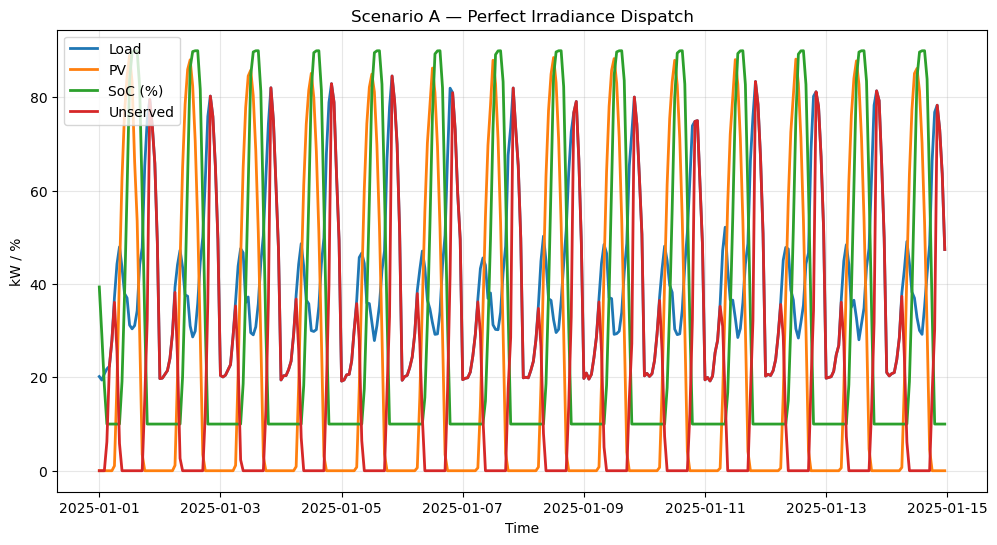

In [54]:
plt.figure(figsize=(12, 6))
plt.plot(A_plot["time"], A_plot["load_kw"], label="Load", linewidth=2)
plt.plot(A_plot["time"], A_plot["pv_ac_kw"], label="PV", linewidth=2)
plt.plot(A_plot["time"], A_plot["soc"] * 100, label="SoC (%)", linewidth=2)
plt.plot(A_plot["time"], A_plot["unserved_load_kw"], label="Unserved", linewidth=2)
plt.xlabel("Time")
plt.ylabel("kW / %")
plt.title("Scenario A — Perfect Irradiance Dispatch")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### ii) Scenario B dispatch plot

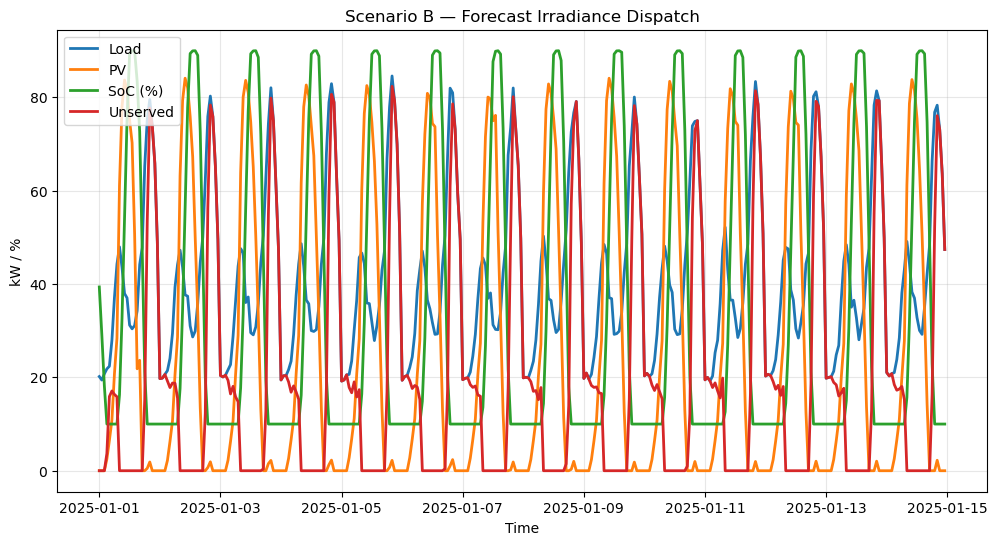

In [55]:
plt.figure(figsize=(12, 6))
plt.plot(B_plot["time"], B_plot["load_kw"], label="Load", linewidth=2)
plt.plot(B_plot["time"], B_plot["pv_ac_kw"], label="PV", linewidth=2)
plt.plot(B_plot["time"], B_plot["soc"] * 100, label="SoC (%)", linewidth=2)
plt.plot(B_plot["time"], B_plot["unserved_load_kw"], label="Unserved", linewidth=2)
plt.xlabel("Time")
plt.ylabel("kW / %")
plt.title("Scenario B — Forecast Irradiance Dispatch")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 08) Better Diagnostic Plot for Batt Power

#### i) Scenario B detailed dispatch plot

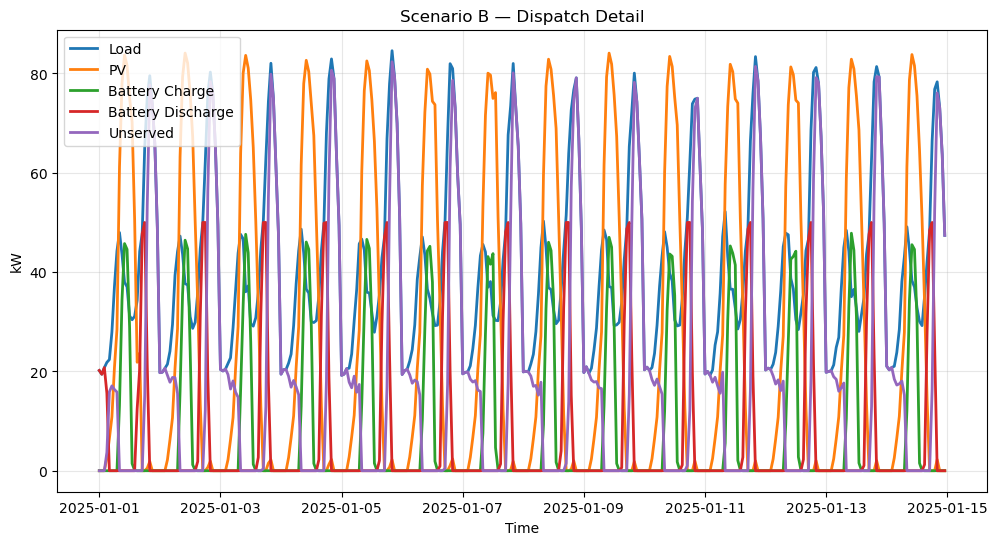

In [56]:
plt.figure(figsize=(12, 6))
plt.plot(B_plot["time"], B_plot["load_kw"], label="Load", linewidth=2)
plt.plot(B_plot["time"], B_plot["pv_ac_kw"], label="PV", linewidth=2)
plt.plot(B_plot["time"], B_plot["charge_kw"], label="Battery Charge", linewidth=2)
plt.plot(B_plot["time"], B_plot["discharge_kw"], label="Battery Discharge", linewidth=2)
plt.plot(B_plot["time"], B_plot["unserved_load_kw"], label="Unserved", linewidth=2)
plt.xlabel("Time")
plt.ylabel("kW")
plt.title("Scenario B — Dispatch Detail")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 09) Dispatch Detail Note

Charge and discharge power are retained explicitly in the simulation outputs
to make battery behavior interpretable during stressful periods.

This helps distinguish between:
- energy surplus absorbed by storage
- evening discharge support
- residual unserved load after battery limits are reached